# Практическое задание №2: Визуализация данных HVAC с помощью лиц Чернова

**Цель:** освоить нестандартные модели визуализации многомерных данных и обосновать их выбор.  
**Данные:** VAST Challenge 2016 Mini-Challenge 2 — система HVAC, 31 мая – 13 июня 2016 г.

## 0. Импорт библиотек

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as mpath
from matplotlib.patches import Ellipse
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print('Библиотеки загружены.')

Библиотеки загружены.


## 1. Вариант и загрузка данных

In [4]:
# ── Вариант ────────────────────────────────────────────────
STUDENT_NUMBER = 237118
VARIANT = STUDENT_NUMBER % 8          # 6
ZONE_MAP = {
    0: 'F_1_Z_1', 1: 'F_1_Z_2', 2: 'F_2_Z_2', 3: 'F_3_Z_1',
    4: 'F_2_Z_4', 5: 'F_3_Z_3', 6: 'F_2_Z_2', 7: 'F_3_Z_8'
}
ZONE = ZONE_MAP[VARIANT]              # 'F_2_Z_2'
print(f'Номер студента : {STUDENT_NUMBER}')
print(f'Вариант        : {VARIANT}')
print(f'Зона           : {ZONE}')

Номер студента : 237118
Вариант        : 6
Зона           : F_2_Z_2


In [5]:
DATA_PATH = 'bldg-MC2.csv'
df_raw = pd.read_csv(DATA_PATH)

# Приводим время к datetime
time_col = df_raw.columns[0]
df_raw[time_col] = pd.to_datetime(df_raw[time_col].str.strip())
df_raw = df_raw.set_index(time_col).sort_index()

# Числовые столбцы
df_raw = df_raw.apply(pd.to_numeric, errors='coerce')

print(f'Датасет: {df_raw.shape[0]} строк × {df_raw.shape[1]} столбцов')
print(f'Период : {df_raw.index.min().date()} — {df_raw.index.max().date()}')

Датасет: 4032 строк × 415 столбцов
Период : 2016-05-31 — 2016-06-13


In [6]:
# Точная фильтрация по зоне (избегаем совпадений с F_2_Z_20, F_2_Z_21 и т.п.)
import re
pattern = re.compile(r'^' + re.escape(ZONE) + r'[\s:_]')
zone_cols = [c for c in df_raw.columns if pattern.match(c.strip())]

# Убираем константные столбцы (setpoints: дисперсия ≈ 0)
df_zone = df_raw[zone_cols].copy()
non_const = df_zone.std() > 0.01
zone_cols = list(non_const[non_const].index)
df_zone = df_zone[zone_cols]

print(f'Параметры зоны {ZONE} (после удаления констант) — {len(zone_cols)} шт.:')
for c in zone_cols:
    print(f'  {c}')

Параметры зоны F_2_Z_2 (после удаления констант) — 10 шт.:
   F_2_Z_2: Lights Power
   F_2_Z_2: Equipment Power
   F_2_Z_2: Thermostat Temp
   F_2_Z_2: Thermostat Heating Setpoint
   F_2_Z_2: Thermostat Cooling Setpoint
   F_2_Z_2 VAV REHEAT Damper Position
   F_2_Z_2 REHEAT COIL Power
   F_2_Z_2 RETURN OUTLET CO2 Concentration
   F_2_Z_2 SUPPLY INLET Temperature
   F_2_Z_2 SUPPLY INLET Mass Flow Rate


## 2. Предварительный анализ данных (EDA)

In [7]:
# Короткие имена для графиков
short = {c: c.replace(ZONE, '').strip(': ').strip() for c in zone_cols}
df_zone.columns = [short[c] for c in zone_cols]
params = list(df_zone.columns)

# Статистики
stat = df_zone.describe().T
stat['variance'] = df_zone.var()
stat['CV%'] = (df_zone.std() / df_zone.mean().abs() * 100).round(1)
print('Описательная статистика:')
display(stat[['mean','std','variance','min','max','CV%']].round(3))

Описательная статистика:


,mean,std,variance,min,max,CV%
Lights Power,1017.130,1212.893,1471109.468,0.000,2463.105,119.2
Equipment Power,914.428,679.220,461339.900,344.835,1724.173,74.3
Thermostat Temp,24.672,1.779,3.165,20.000,29.711,7.2
Thermostat Heating Setpoint,20.307,4.072,16.581,12.600,26.670,20.1
Thermostat Cooling Setpoint,25.013,2.965,8.793,15.560,29.700,11.9
VAV REHEAT Damper Position,0.571,0.382,0.146,0.000,1.000,66.9
REHEAT COIL Power,686.091,1588.876,2524525.916,0.000,12927.501,231.6
RETURN OUTLET CO2 Concentration,991.333,504.688,254709.985,430.286,2978.369,50.9
SUPPLY INLET Temperature,14.601,3.649,13.312,12.188,40.039,25.0
SUPPLY INLET Mass Flow Rate,0.302,0.202,0.041,0.000,0.528,66.9


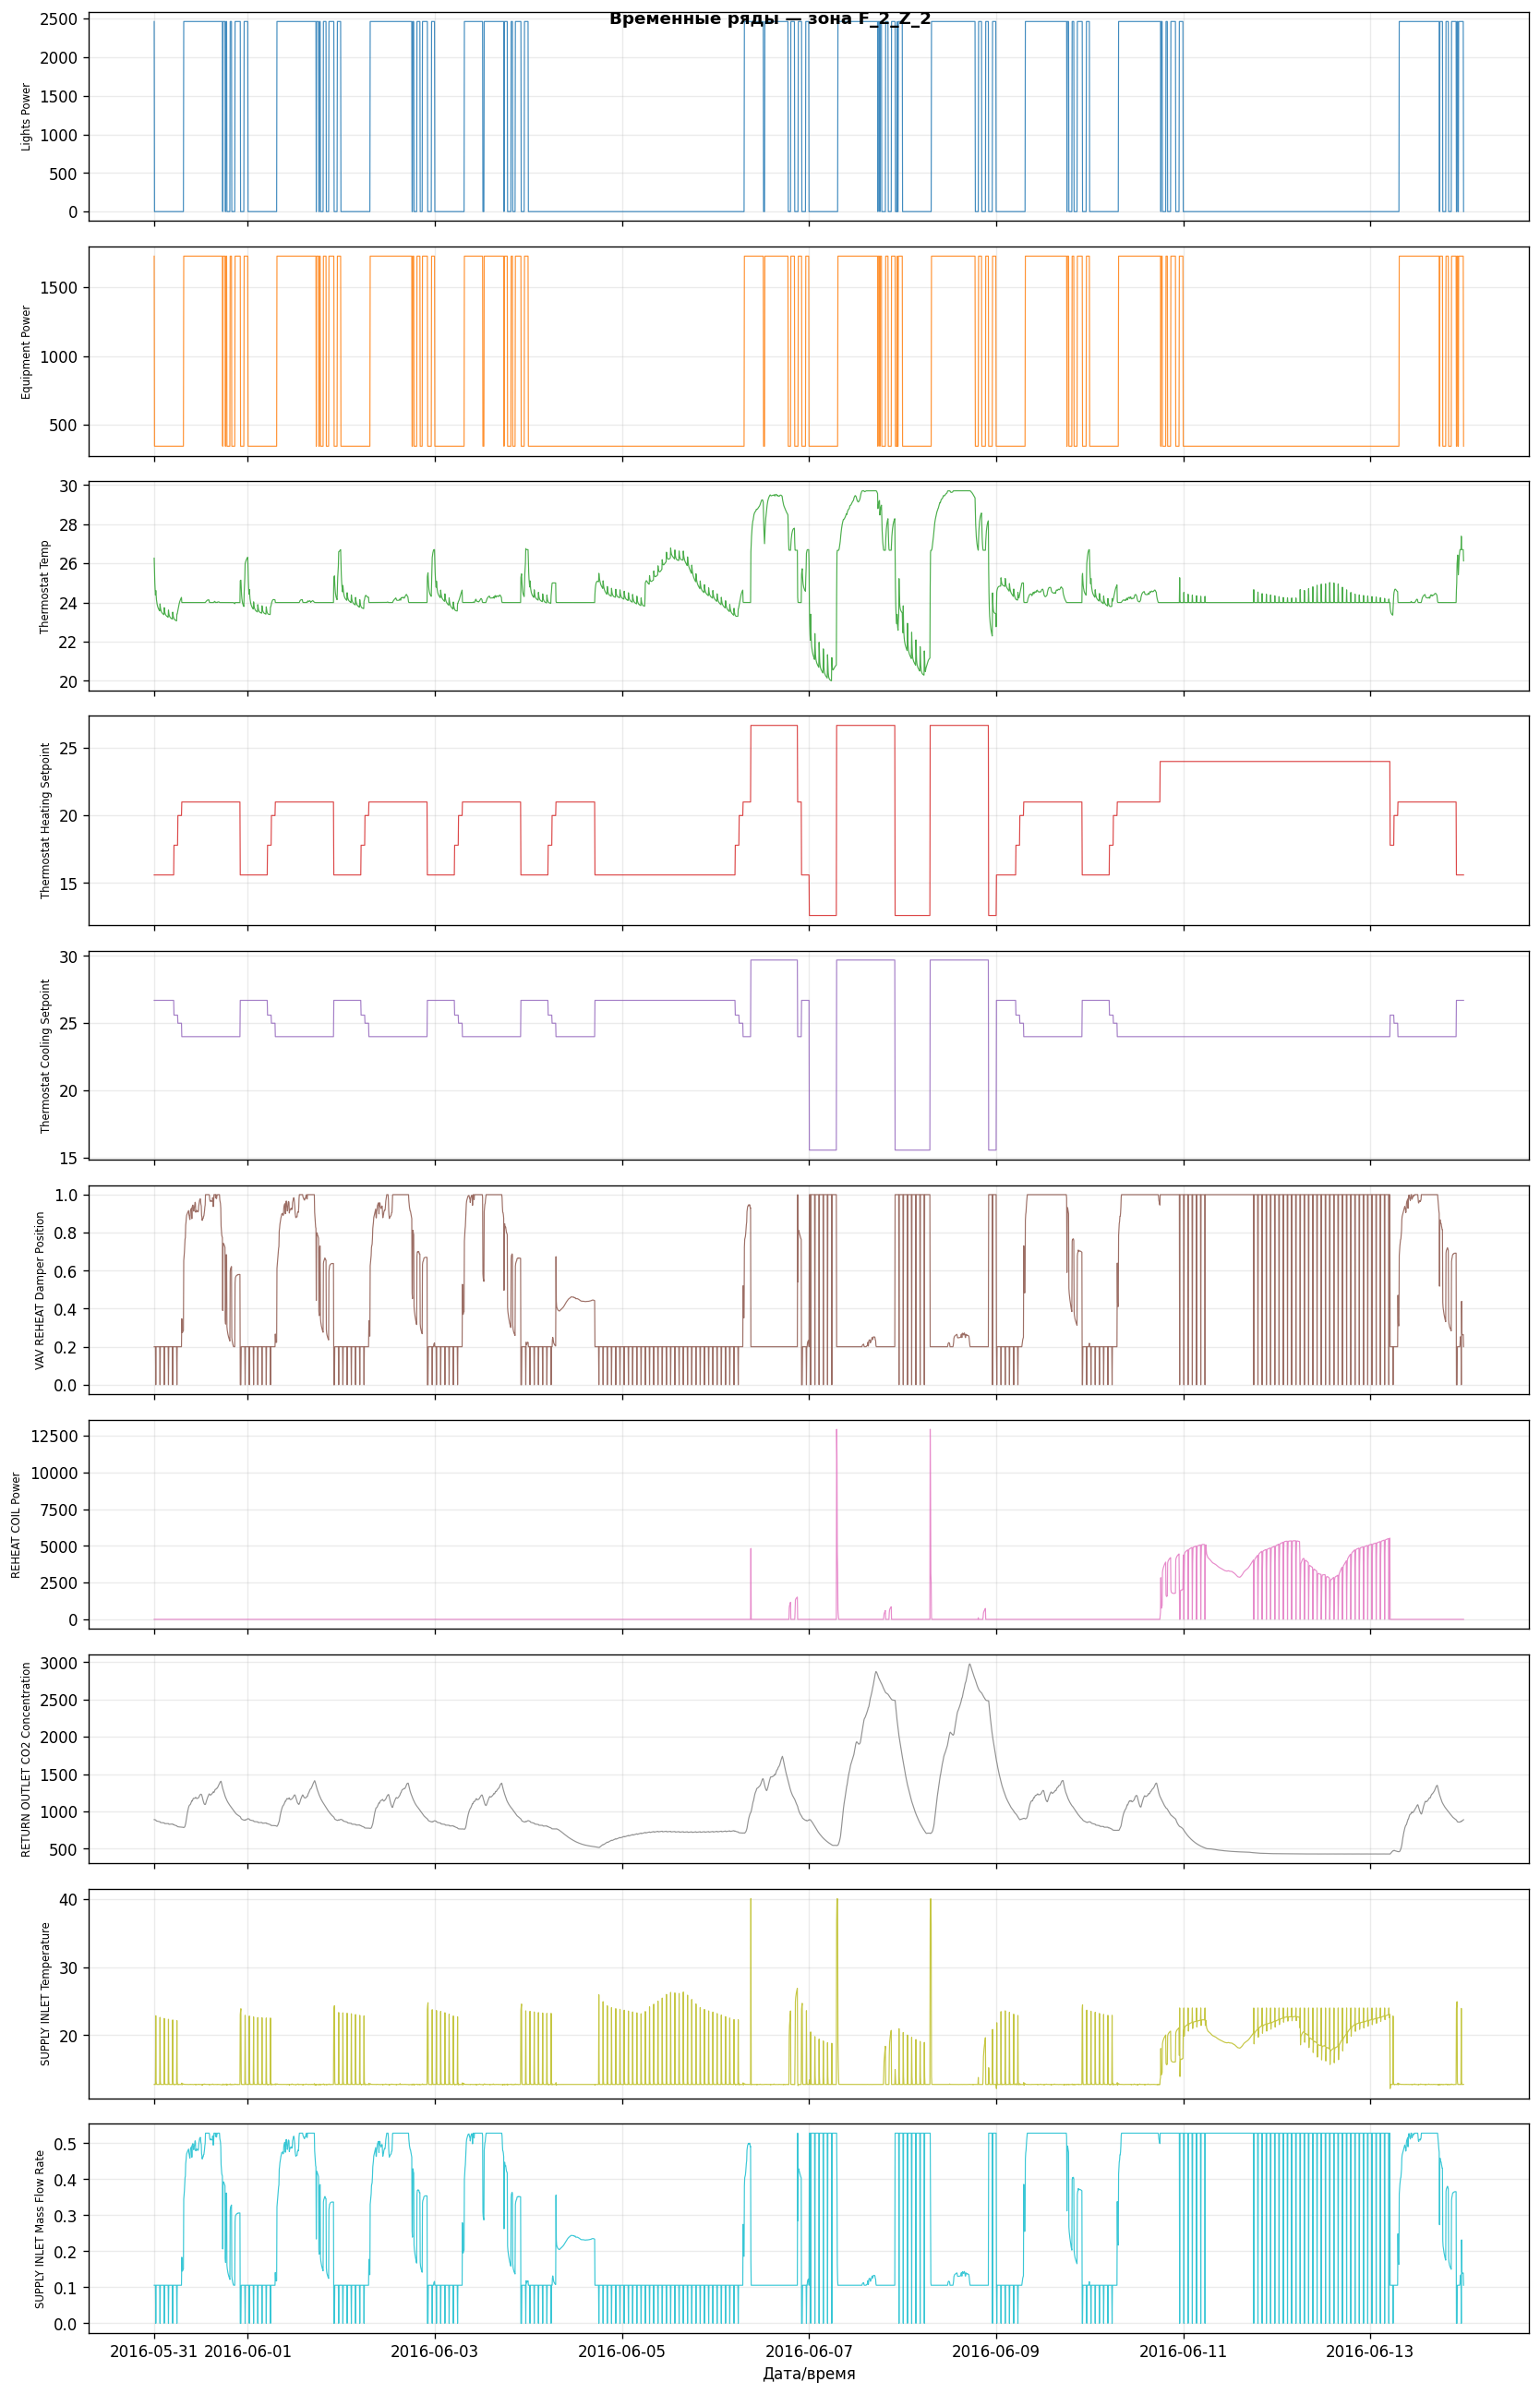

In [8]:
# Временные ряды
n = len(params)
fig, axes = plt.subplots(n, 1, figsize=(14, 2.2*n), sharex=True)
if n == 1: axes = [axes]
colors = plt.cm.tab10(np.linspace(0, 1, n))
for ax, col, clr in zip(axes, params, colors):
    ax.plot(df_zone.index, df_zone[col], color=clr, lw=0.7, alpha=0.85)
    ax.set_ylabel(col, fontsize=7)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Дата/время')
fig.suptitle(f'Временные ряды — зона {ZONE}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('time_series.png', bbox_inches='tight', dpi=150)
plt.show()

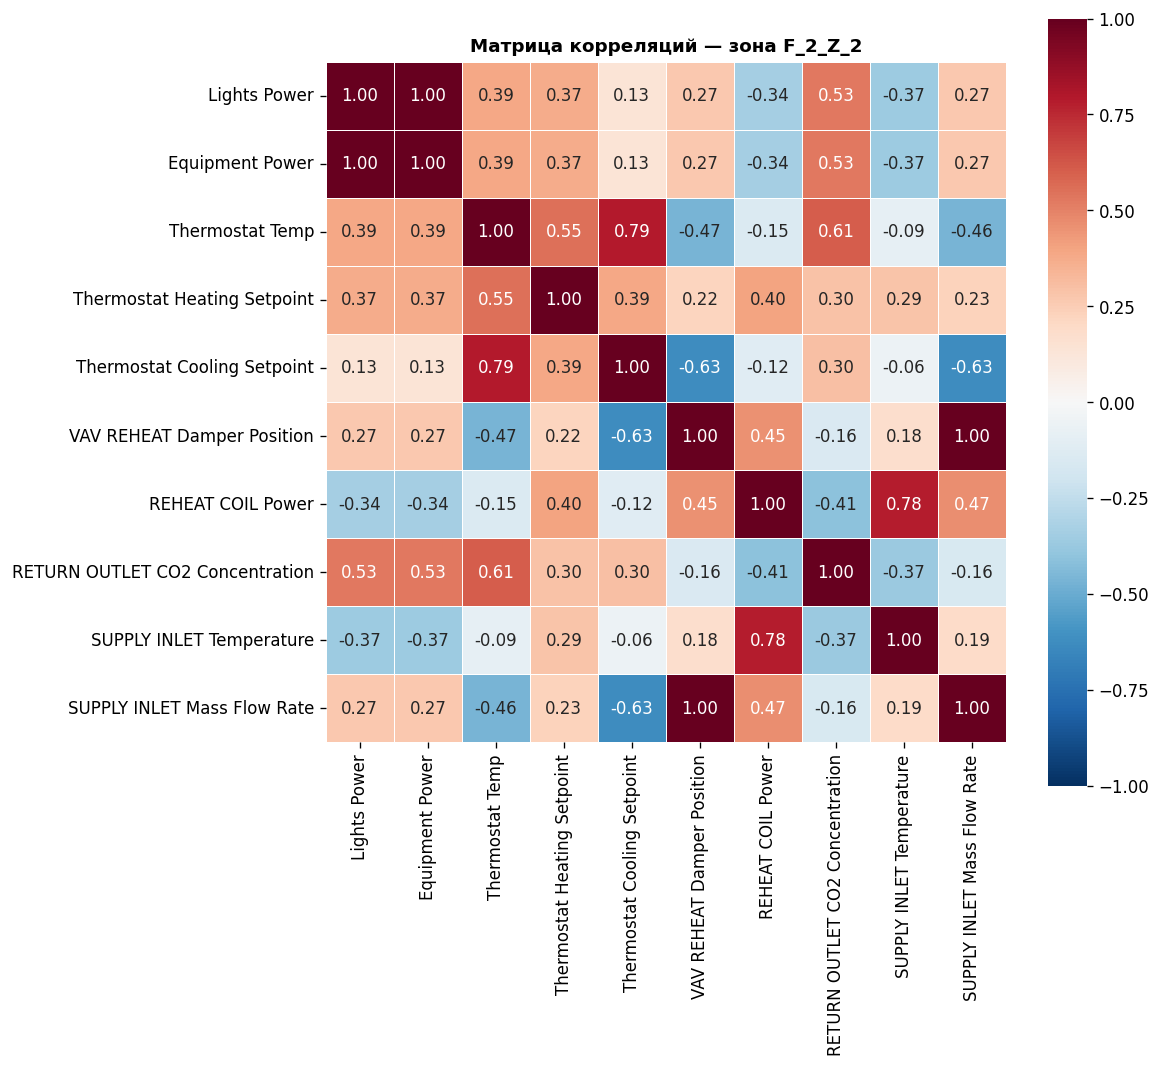

Сильные корреляции (|r| > 0.7):
  Equipment Power                          & Lights Power                              r=+1.000
  Thermostat Cooling Setpoint              & Thermostat Temp                           r=+0.794
  SUPPLY INLET Temperature                 & REHEAT COIL Power                         r=+0.785
  SUPPLY INLET Mass Flow Rate              & VAV REHEAT Damper Position                r=+0.998


In [9]:
# Матрица корреляций
corr = df_zone.corr()
fig, ax = plt.subplots(figsize=(max(8, n), max(6, n-1)))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title(f'Матрица корреляций — зона {ZONE}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print('Сильные корреляции (|r| > 0.7):')
for i in range(len(corr.columns)):
    for j in range(i):
        v = corr.iloc[i,j]
        if abs(v) > 0.7:
            print(f'  {corr.columns[i]:40s} & {corr.columns[j]:40s}  r={v:+.3f}')

In [10]:
# Суточные агрегаты
df_zone['_day'] = df_zone.index.date
days = sorted(df_zone['_day'].unique())
print(f'Дней в датасете: {len(days)}')

data_cols = [c for c in df_zone.columns if c != '_day']
daily_mean = df_zone.groupby('_day')[data_cols].mean()
daily_std  = df_zone.groupby('_day')[data_cols].std()
df_zone.drop(columns='_day', inplace=True)

print('\nСуточные средние:')
display(daily_mean.round(2))

Дней в датасете: 14

Суточные средние:


,Lights Power,Equipment Power,Thermostat Temp,Thermostat Heating Setpoint,Thermostat Cooling Setpoint,VAV REHEAT Damper Position,REHEAT COIL Power,RETURN OUTLET CO2 Concentration,SUPPLY INLET Temperature,SUPPLY INLET Mass Flow Rate
_day,,,,,,,,,,
2016-05-31,1402.60,1130.29,23.98,19.25,24.90,0.55,0.00,1025.19,13.16,0.29
2016-06-01,1436.81,1149.45,24.07,19.25,24.90,0.56,0.00,1030.09,13.17,0.30
2016-06-02,1445.36,1154.24,24.19,19.25,24.90,0.58,0.00,1008.06,13.19,0.31
2016-06-03,1394.05,1125.50,24.23,19.25,24.90,0.59,0.00,1002.62,13.19,0.31
2016-06-04,0.00,344.83,24.29,18.12,25.46,0.29,0.00,667.27,13.28,0.15
2016-06-05,0.00,344.83,25.12,15.60,26.70,0.18,0.00,716.85,13.74,0.10
2016-06-06,1402.60,1130.29,26.36,22.08,27.75,0.27,70.57,1086.38,13.77,0.14
2016-06-07,1428.26,1144.66,25.95,21.40,24.44,0.48,141.20,1648.16,13.66,0.25
2016-06-08,1411.15,1135.08,26.15,21.39,24.40,0.49,112.72,1815.21,13.52,0.26


## 3. Нормализация и схема кодирования

In [11]:
scaler = MinMaxScaler()
daily_norm = pd.DataFrame(
    scaler.fit_transform(daily_mean),
    index=daily_mean.index,
    columns=daily_mean.columns
)

# Ранжируем по дисперсии суточных средних (убывание)
var_rank  = daily_norm.var().sort_values(ascending=False)
ranked    = var_rank.index.tolist()
n_params  = len(ranked)

print('Параметры по убыванию дисперсии суточных средних:')
for i,(p,v) in enumerate(var_rank.items()):
    print(f'  {i+1}. {p:45s} var={v:.5f}')

Параметры по убыванию дисперсии суточных средних:
  1. Lights Power                                  var=0.20148
  2. Equipment Power                               var=0.20148
  3. Thermostat Temp                               var=0.12944
  4. REHEAT COIL Power                             var=0.12299
  5. SUPPLY INLET Temperature                      var=0.11809
  6. VAV REHEAT Damper Position                    var=0.08692
  7. SUPPLY INLET Mass Flow Rate                   var=0.08667
  8. RETURN OUTLET CO2 Concentration               var=0.07670
  9. Thermostat Cooling Setpoint                   var=0.07643
  10. Thermostat Heating Setpoint                   var=0.07182


In [12]:
def gp(idx):
    """Вернуть имя параметра по рангу или None."""
    return ranked[idx] if idx < n_params else None

# ── Схема кодирования ─────────────────────────────────────────────────────
# Наиболее информативные параметры (высокая дисперсия) → черты,
# которые человек различает точнее всего (Моррис и др., 2000):
#   1. Размер глаз  — самая точная черта
#   2. Наклон бровей — вторая по точности
# Остальные параметры → рот, нос, зрачки, волосы, ширина лица.
# ──────────────────────────────────────────────────────────────────────────
MAPPING = {
    'eye_size'      : gp(0),   # ★ САМЫЙ важный параметр
    'eyebrow_slope' : gp(1),   # ★ второй по важности
    'mouth_curve'   : gp(2),   # кривизна рта (улыбка ↔ грусть)
    'pupil_size'    : gp(3),   # размер зрачков
    'face_width'    : gp(4),   # ширина лица
    'hair_darkness' : gp(5),   # темнота волос
    'nose_length'   : gp(6),   # длина носа
    'mouth_width'   : gp(7),   # ширина рта
    'eyebrow_height': gp(8),   # высота бровей
}

feat_ru = {
    'eye_size'      : 'Размер глаз',
    'eyebrow_slope' : 'Наклон бровей',
    'mouth_curve'   : 'Кривизна рта',
    'pupil_size'    : 'Зрачки',
    'face_width'    : 'Ширина лица',
    'hair_darkness' : 'Темнота волос',
    'nose_length'   : 'Нос',
    'mouth_width'   : 'Ширина рта',
    'eyebrow_height': 'Высота бровей',
}

print('СХЕМА КОДИРОВАНИЯ')
print('─' * 70)
for feat, pname in MAPPING.items():
    print(f'  {feat_ru[feat]:20s} ← {pname if pname else "(не используется)"}')

СХЕМА КОДИРОВАНИЯ
──────────────────────────────────────────────────────────────────────
  Размер глаз          ← Lights Power
  Наклон бровей        ← Equipment Power
  Кривизна рта         ← Thermostat Temp
  Зрачки               ← REHEAT COIL Power
  Ширина лица          ← SUPPLY INLET Temperature
  Темнота волос        ← VAV REHEAT Damper Position
  Нос                  ← SUPPLY INLET Mass Flow Rate
  Ширина рта           ← RETURN OUTLET CO2 Concentration
  Высота бровей        ← Thermostat Cooling Setpoint


## 4. Функция рисования лица Чернова

In [13]:
def gv(row, key, default=0.5):
    """Нормализованное значение [0..1] для черты лица."""
    p = MAPPING.get(key)
    if p and p in row.index:
        return float(np.clip(row[p], 0, 1))
    return default


def draw_face(ax, row, title=''):
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.45, 1.45)
    ax.set_aspect('equal')
    ax.axis('off')

    # ── Параметры → геометрия ────────────────────────────────────
    eye_sz   = 0.09 + gv(row,'eye_size')      * 0.19   # [0.09, 0.28]
    eb_slope = (gv(row,'eyebrow_slope') - 0.5) * 34    # [-17, +17]°
    m_curve  = (gv(row,'mouth_curve')   - 0.5) * 0.30  # [-0.15, +0.15]
    pup_sz   = 0.03 + gv(row,'pupil_size')    * 0.07
    fw       = 0.72 + gv(row,'face_width')    * 0.46   # [0.72, 1.18]
    hair_l   = 1.0  - gv(row,'hair_darkness') * 0.72   # [0.28, 1.0]
    nose_l   = 0.10 + gv(row,'nose_length')   * 0.16
    m_half   = 0.18 + gv(row,'mouth_width')   * 0.30
    eb_y     = 0.44 + gv(row,'eyebrow_height')* 0.26

    avg       = float(row.mean())
    face_rgba = plt.cm.RdYlGn(0.18 + avg * 0.64)

    # ── Волосы (фоновый эллипс) ──────────────────────────────────
    ax.add_patch(Ellipse((0, 0.18), fw*2, 2.55,
                         color=(hair_l, hair_l*0.84, hair_l*0.58), zorder=1))

    # ── Лицо ────────────────────────────────────────────────────
    ax.add_patch(Ellipse((0, 0), fw*2, 2.0,
                         color=face_rgba[:3], ec='#444', lw=1.1, zorder=2))

    # ── Глаза ───────────────────────────────────────────────────
    for ex in (-0.34, 0.34):
        ey = 0.30
        ax.add_patch(Ellipse((ex, ey), eye_sz*2.9, eye_sz*2.1,
                             color='white', ec='#333', lw=0.8, zorder=3))
        ax.add_patch(Ellipse((ex, ey), pup_sz*2, pup_sz*2,
                             color='#111', zorder=4))
        ax.add_patch(Ellipse((ex+pup_sz*0.45, ey+pup_sz*0.45),
                             pup_sz*0.55, pup_sz*0.55,
                             color='white', zorder=5))

    # ── Брови ───────────────────────────────────────────────────
    for sign, bx in ((-1, -0.34), (1, 0.34)):
        hl = 0.23
        ang = np.radians(eb_slope * sign)
        dx, dy = hl*np.cos(ang), hl*np.sin(ang)
        ax.plot([bx-dx, bx+dx], [eb_y-dy, eb_y+dy],
                color='#2e1a0e', lw=2.6, solid_capstyle='round', zorder=6)

    # ── Нос ─────────────────────────────────────────────────────
    ny0, ny1 = -0.04, -0.04 - nose_l
    nose = mpath.Path(
        [(0,ny0),(-0.09,ny1),(0.09,ny1)],
        [mpath.Path.MOVETO, mpath.Path.CURVE3, mpath.Path.CURVE3])
    ax.add_patch(mpatches.PathPatch(nose, fc='none',
                                    ec='#5a4030', lw=1.1, zorder=6))

    # ── Рот ─────────────────────────────────────────────────────
    my = -0.47
    t  = np.linspace(0, np.pi, 60)
    ax.plot(m_half*np.cos(t),
            my + m_curve*np.sin(t),
            color='#8b3a3a', lw=2.1, solid_capstyle='round', zorder=6)

    if title:
        ax.set_title(title, fontsize=8, pad=2, fontweight='bold')


print('Функция draw_face готова.')

Функция draw_face готова.


## 5. Схема визуализации (рис. 2 / рис. 11 из задания)

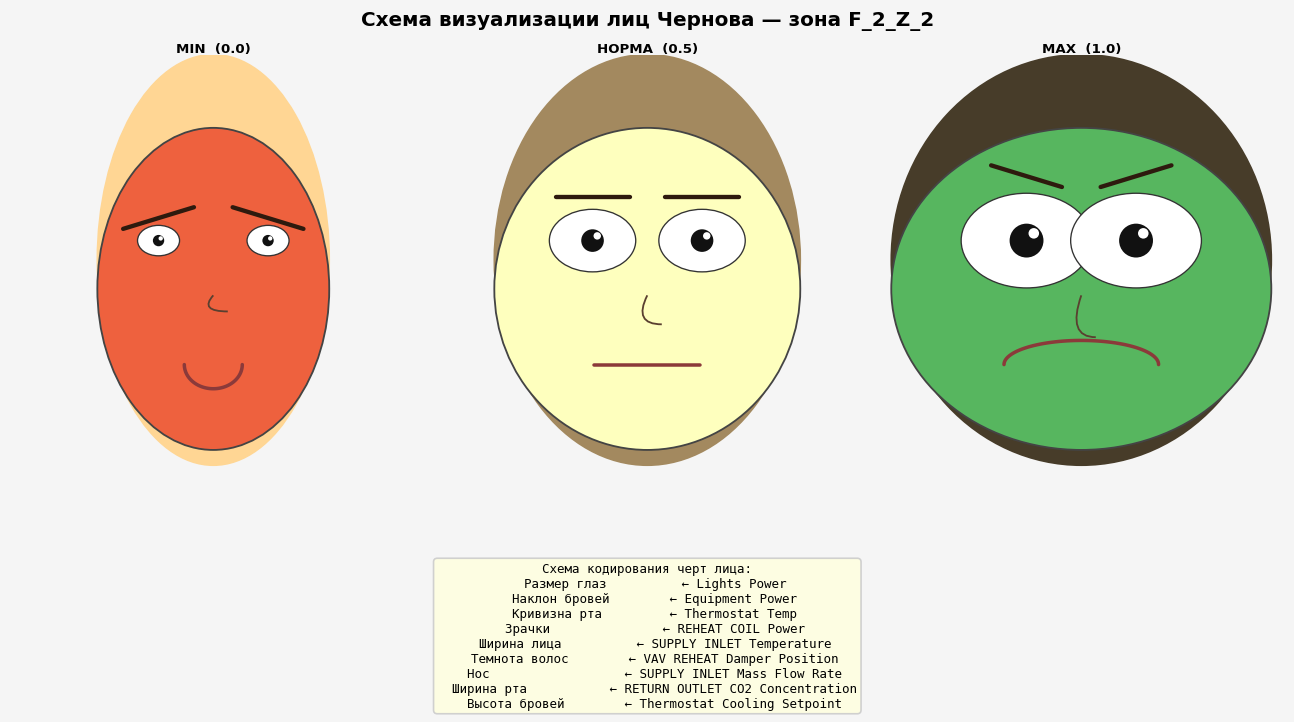

Сохранено: chernoff_schema.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4.5))
fig.patch.set_facecolor('#f5f5f5')

for ax, val, label in zip(axes,
                           [0.0, 0.5, 1.0],
                           ['MIN  (0.0)', 'НОРМА  (0.5)', 'MAX  (1.0)']):
    row = pd.Series({p: val for p in params})
    draw_face(ax, row, title=label)
    ax.set_facecolor('#f5f5f5')

# Блок легенды
lines = ['Схема кодирования черт лица:']
for feat, pname in MAPPING.items():
    if pname:
        lines.append(f'  {feat_ru[feat]:20s} ← {pname}')
fig.text(0.5, -0.04, '\n'.join(lines), ha='center', va='top',
         fontsize=7.5, family='monospace',
         bbox=dict(boxstyle='round', fc='lightyellow', ec='#ccc', alpha=0.9))

fig.suptitle(f'Схема визуализации лиц Чернова — зона {ZONE}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chernoff_schema.png', bbox_inches='tight', dpi=150, facecolor='#f5f5f5')
plt.show()
print('Сохранено: chernoff_schema.png')

## 6. Основная визуализация: 14 дней календарём

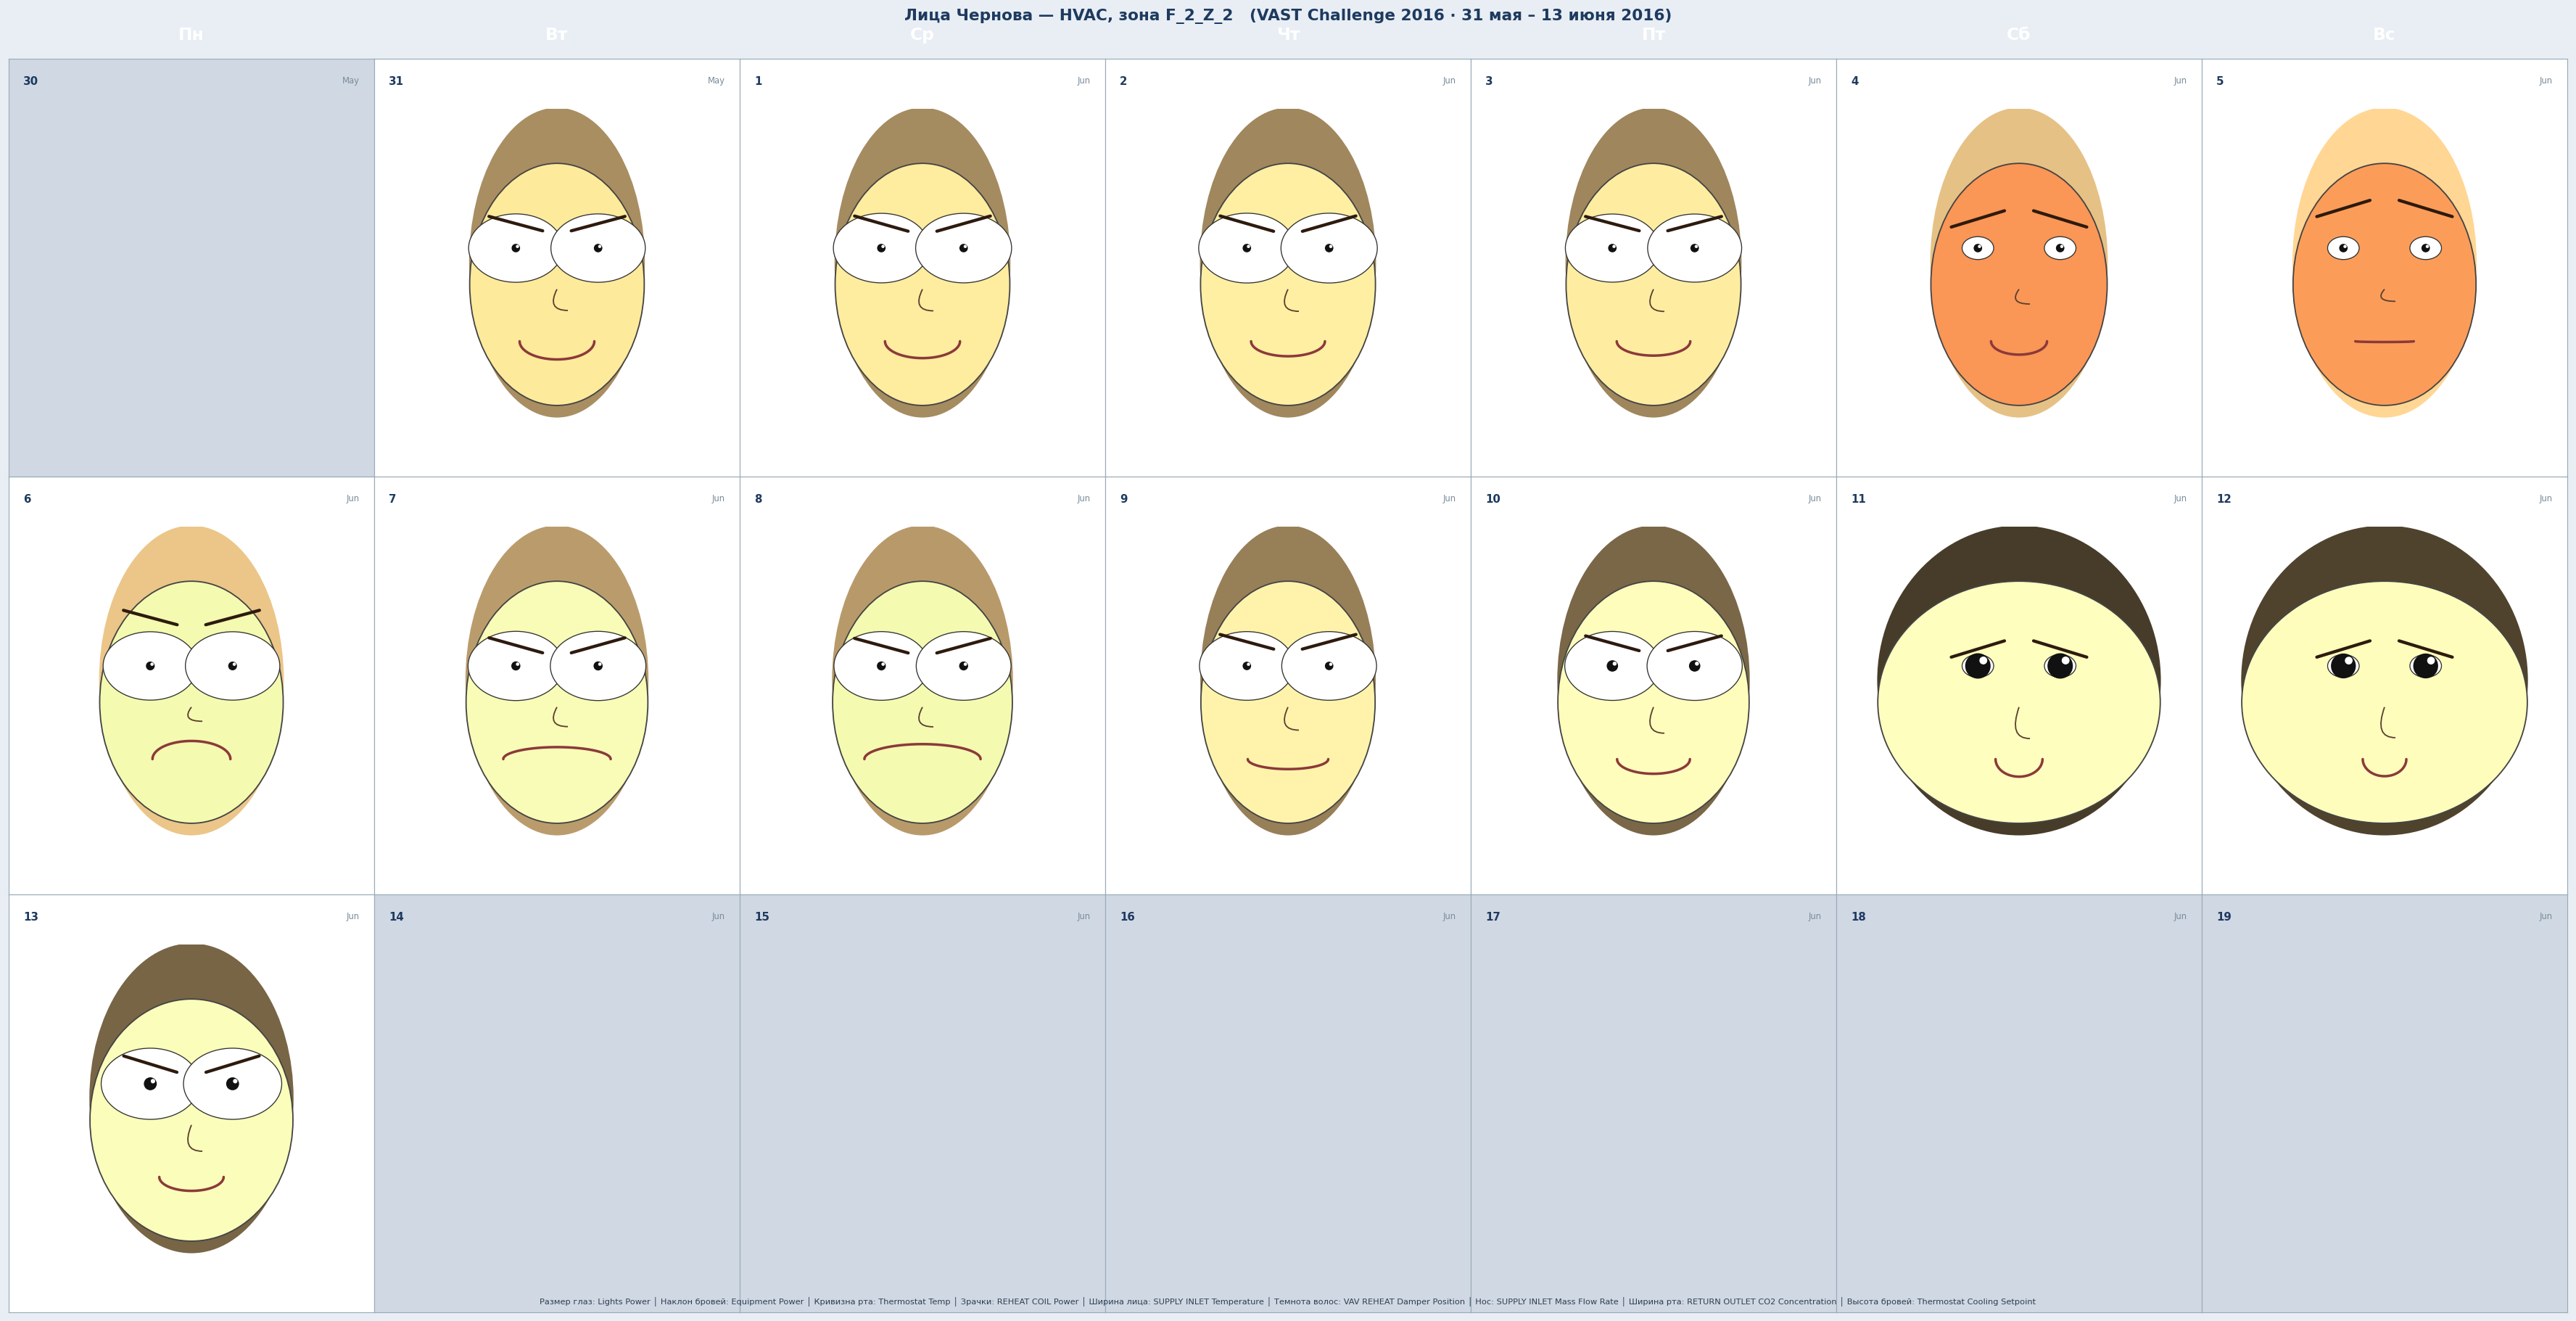

Сохранено: chernoff_calendar.png


In [15]:
from datetime import timedelta

def calendar_grid(days):
    start = days[0]
    grid_start = start - timedelta(days=start.weekday())
    end = days[-1]
    grid_end = end + timedelta(days=(6 - end.weekday()))
    grid, row, cur = [], [], grid_start
    while cur <= grid_end:
        row.append(cur)
        if len(row) == 7:
            grid.append(row); row = []
        cur += timedelta(days=1)
    if row: grid.append(row)
    return grid

grid    = calendar_grid(days)
nrows   = len(grid)
days_set = set(days)
DAY_NAMES = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

CW = 4.2   # ширина ячейки, дюймы
CH = 4.8   # высота ячейки
HDR = 0.55 # высота строки с днями недели

fig_w = CW * 7
fig_h = CH * nrows + HDR

fig = plt.figure(figsize=(fig_w, fig_h))
fig.patch.set_facecolor('#e8eef4')

total_h = fig_h

# Заголовки дней недели
for j, dn in enumerate(DAY_NAMES):
    ax = fig.add_axes([j/7, 1 - HDR/total_h, 1/7, HDR/total_h])
    ax.set_facecolor('#1e3a5f')
    ax.text(0.5, 0.5, dn, ha='center', va='center',
            fontsize=14, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.axis('off')

body_h   = 1 - HDR/total_h
cell_h   = body_h / nrows
cell_w   = 1.0 / 7

for i, row_dates in enumerate(grid):
    for j, d in enumerate(row_dates):
        left   = j * cell_w
        bottom = body_h - (i+1)*cell_h

        # Фон ячейки
        ax_bg = fig.add_axes([left, bottom, cell_w, cell_h])
        bg_clr = '#ffffff' if d in days_set else '#d0d8e4'
        ax_bg.set_facecolor(bg_clr)
        for sp in ax_bg.spines.values():
            sp.set_edgecolor('#9aabb8'); sp.set_linewidth(0.7)
        ax_bg.set_xticks([]); ax_bg.set_yticks([])
        ax_bg.text(0.04, 0.96, str(d.day), transform=ax_bg.transAxes,
                   fontsize=9, fontweight='bold', va='top', color='#1e3a5f')
        ax_bg.text(0.96, 0.96, d.strftime('%b'), transform=ax_bg.transAxes,
                   fontsize=7, va='top', ha='right', color='#7a8c9a')

        # Лицо
        if d in days_set:
            m = 0.06
            ax_f = fig.add_axes([left + cell_w*m,
                                  bottom + cell_h*0.04,
                                  cell_w*(1-2*m),
                                  cell_h*0.84])
            draw_face(ax_f, daily_norm.loc[d])

# Легенда внизу
leg_items = ' │ '.join(
    f'{feat_ru[f]}: {p}' for f,p in MAPPING.items() if p
)
fig.text(0.5, 0.005, leg_items, ha='center', va='bottom',
         fontsize=6.8, color='#2c3e50')

fig.suptitle(
    f'Лица Чернова — HVAC, зона {ZONE}   (VAST Challenge 2016 · 31 мая – 13 июня 2016)',
    fontsize=13, fontweight='bold', y=1.002, color='#1e3a5f'
)

plt.savefig('chernoff_calendar.png', bbox_inches='tight', dpi=150, facecolor='#e8eef4')
plt.show()
print('Сохранено: chernoff_calendar.png')

## 7. Обнаружение аномальных дней

In [16]:
# Z-score суточных средних
daily_z = daily_mean.apply(zscore, nan_policy='omit')
anom_score = daily_z.abs().max(axis=1)
THRESH = 2.0
anom_days = anom_score[anom_score > THRESH].sort_values(ascending=False)

print(f'Порог |z| > {THRESH}')
print(f'Аномальных дней: {len(anom_days)} из {len(days)}\n')
for d, sc in anom_days.items():
    top = daily_z.loc[d].abs().idxmax()
    print(f'  {d}  max|z|={sc:.2f}  причина: {top}')

Порог |z| > 2.0
Аномальных дней: 5 из 14

  2016-06-06  max|z|=2.74  причина: Thermostat Cooling Setpoint
  2016-06-12  max|z|=2.44  причина: SUPPLY INLET Temperature
  2016-06-11  max|z|=2.43  причина: REHEAT COIL Power
  2016-06-08  max|z|=2.23  причина: RETURN OUTLET CO2 Concentration
  2016-06-05  max|z|=2.17  причина: Thermostat Heating Setpoint


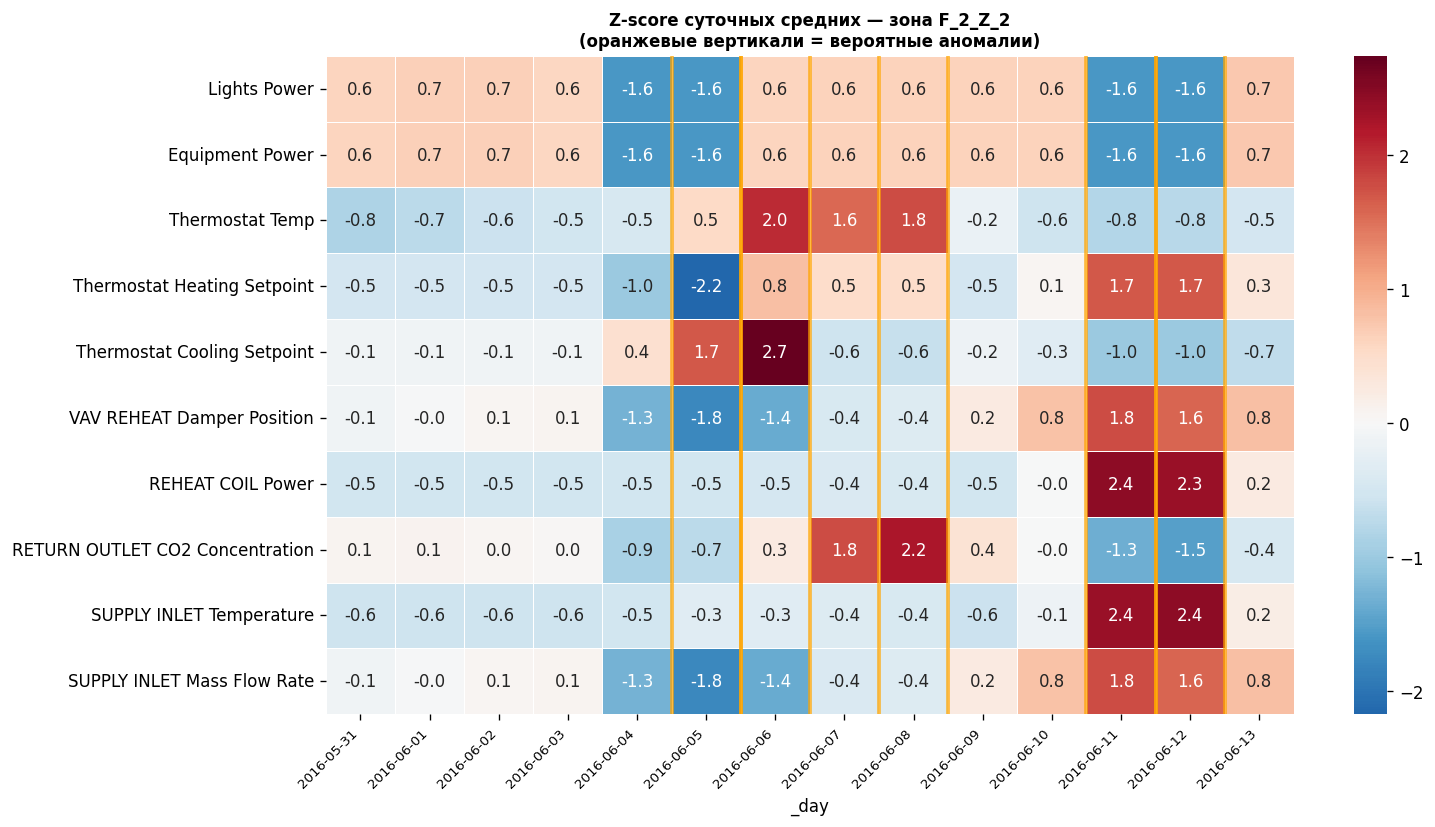

In [17]:
# Тепловая карта z-score
fig, ax = plt.subplots(figsize=(13, max(4, len(params)//2 + 2)))
sns.heatmap(daily_z.T, cmap='RdBu_r', center=0,
            annot=True, fmt='.1f', linewidths=0.4,
            xticklabels=[str(d) for d in daily_z.index],
            yticklabels=daily_z.columns, ax=ax)

for d in anom_days.index:
    ci = list(daily_z.index).index(d)
    ax.axvline(ci,   color='orange', lw=2.2, alpha=0.75)
    ax.axvline(ci+1, color='orange', lw=2.2, alpha=0.75)

ax.set_title(f'Z-score суточных средних — зона {ZONE}\n'
             '(оранжевые вертикали = вероятные аномалии)',
             fontsize=10, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('anomaly_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Обоснование визуального дизайна

In [18]:
print("""
ОБОСНОВАНИЕ ВЫБОРА ВИЗУАЛЬНОГО ДИЗАЙНА
═══════════════════════════════════════

1. МЕТАФОРА
   Лицо Чернова выбрано намеренно: состояние системы HVAC напрямую
   влияет на комфорт людей в здании. «Довольное» лицо — комфортная
   среда; «грустное/напряжённое» — аномалия или дискомфорт.
   Это усиливает интуитивность восприятия для нетехнической аудитории.

2. ПРИОРИТЕТ ЧЕРТ (Morris et al., 2000)
   Размер глаз и наклон бровей воспринимаются точнее всего.
   → Им назначены параметры с НАИБОЛЬШЕЙ дисперсией суточных средних
     (ранжирование по дисперсии = автоматический выбор наиболее
     «информативных» параметров для обнаружения отклонений).

3. КРИВИЗНА РТА
   Интуитивна без легенды: улыбка (высокое значение) = норма,
   опущенные уголки (низкое значение) = проблема.

4. ЦВЕТ ЛИЦА
   Цветовая шкала RdYlGn: красный → жёлтый → зелёный.
   Отражает среднее по всем параметрам зоны.
   Нездоровый красноватый оттенок = аномальный день.

5. НОРМАЛИЗАЦИЯ
   MinMaxScaler по всему 14-дневному периоду.
   Постоянные столбцы (setpoints) исключены — они не несут
   информации об аномалиях.

6. РАСПОЛОЖЕНИЕ
   Дни — в виде реального календаря, что позволяет сравнивать
   одинаковые дни недели (будни vs выходные) и видеть недельные
   паттерны поведения системы.
""")


ОБОСНОВАНИЕ ВЫБОРА ВИЗУАЛЬНОГО ДИЗАЙНА
═══════════════════════════════════════

1. МЕТАФОРА
   Лицо Чернова выбрано намеренно: состояние системы HVAC напрямую
   влияет на комфорт людей в здании. «Довольное» лицо — комфортная
   среда; «грустное/напряжённое» — аномалия или дискомфорт.
   Это усиливает интуитивность восприятия для нетехнической аудитории.

2. ПРИОРИТЕТ ЧЕРТ (Morris et al., 2000)
   Размер глаз и наклон бровей воспринимаются точнее всего.
   → Им назначены параметры с НАИБОЛЬШЕЙ дисперсией суточных средних
     (ранжирование по дисперсии = автоматический выбор наиболее
     «информативных» параметров для обнаружения отклонений).

3. КРИВИЗНА РТА
   Интуитивна без легенды: улыбка (высокое значение) = норма,
   опущенные уголки (низкое значение) = проблема.

4. ЦВЕТ ЛИЦА
   Цветовая шкала RdYlGn: красный → жёлтый → зелёный.
   Отражает среднее по всем параметрам зоны.
   Нездоровый красноватый оттенок = аномальный день.

5. НОРМАЛИЗАЦИЯ
   MinMaxScaler по всему 14-дневном

## 9. Ответы на контрольные вопросы

In [19]:
print('── Вопрос 1: В какие дни возникали аномалии? ──')
if len(anom_days):
    for d, sc in anom_days.items():
        top = daily_z.loc[d].abs().idxmax()
        print(f'  {d}  ({d.strftime("%A")})  max|z|={sc:.2f}  → {top}')
else:
    print('  Аномалий не обнаружено при |z| > 2.0')

print()
print('── Вопрос 2: Какие параметры связаны с аномалиями? ──')
cnt = {}
for d in anom_days.index:
    for p in daily_z.columns:
        if abs(daily_z.loc[d, p]) > THRESH:
            cnt[p] = cnt.get(p, 0) + 1
for p, c in sorted(cnt.items(), key=lambda x: -x[1]):
    print(f'  {p}: {c} день(ей)')

── Вопрос 1: В какие дни возникали аномалии? ──
  2016-06-06  (Monday)  max|z|=2.74  → Thermostat Cooling Setpoint
  2016-06-12  (Sunday)  max|z|=2.44  → SUPPLY INLET Temperature
  2016-06-11  (Saturday)  max|z|=2.43  → REHEAT COIL Power
  2016-06-08  (Wednesday)  max|z|=2.23  → RETURN OUTLET CO2 Concentration
  2016-06-05  (Sunday)  max|z|=2.17  → Thermostat Heating Setpoint

── Вопрос 2: Какие параметры связаны с аномалиями? ──
  REHEAT COIL Power: 2 день(ей)
  SUPPLY INLET Temperature: 2 день(ей)
  Thermostat Temp: 1 день(ей)
  Thermostat Cooling Setpoint: 1 день(ей)
  RETURN OUTLET CO2 Concentration: 1 день(ей)
  Thermostat Heating Setpoint: 1 день(ей)


In [20]:
print('Созданные файлы:')
for f in ['time_series.png','correlation_matrix.png',
          'chernoff_schema.png','chernoff_calendar.png','anomaly_heatmap.png']:
    print(f'  {"✓" if os.path.exists(f) else "✗"} {f}')

Созданные файлы:
  ✓ time_series.png
  ✓ correlation_matrix.png
  ✓ chernoff_schema.png
  ✓ chernoff_calendar.png
  ✓ anomaly_heatmap.png
